In [1]:
!pip install pandas matplotlib seaborn
!pip install sqlalchemy
!pip install openpyxl


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import sqlite3
import os
import seaborn  as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from matplotlib.ticker import FuncFormatter

In [3]:
pd.options.mode.chained_assignment = None
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)
%matplotlib inline

# 1. Data Preparation & Exploratory Data Analysis

### check what the data is, and see descriptive analysis

In [4]:
df_txn_raw = pd.read_excel("/Users/ying/Documents/MasseyUni/MasseyUni_Learning_Business Analytics/capstone project/UCG Data.xlsx",sheet_name="Transaction dataset",header=0)
df_txn = df_txn_raw.copy()
df_supplementary_raw = pd.read_excel("/Users/ying/Documents/MasseyUni/MasseyUni_Learning_Business Analytics/capstone project/UCG Data.xlsx",sheet_name="Supplementary Data",header=0)
df_supplementary = df_supplementary_raw.copy()
df_soh_raw = pd.read_csv("/Users/ying/Documents/MasseyUni/MasseyUni_Learning_Business Analytics/capstone project/UCGSOH.csv",header=0)
df_soh = df_soh_raw.copy()
print("data successfully loaded")

data successfully loaded


In [5]:
df_txn_raw
df_supplementary_raw
df_soh_raw

,SnapshotDateID,WarehouseName,ProductCode,QtyOnHand
0,20240901,Hamilton,10030300,6.0
1,20240901,Hamilton,10030314,160.0
2,20240901,Hamilton,10030414,2.0
3,20240901,Hamilton,10030832,671.0
4,20240901,Hamilton,10030838,269.0
...,...,...,...,...
619568,20251126,Whangarei,UCG_NC_000579,0.0
619569,20251126,Whangarei,UCG_NC_000593,0.0
619570,20251126,Whangarei,UCG_NC_000650,0.0
619571,20251126,Whangarei,UCG_NC_000651,0.0


In [6]:
df_txn.info() # display data types and non-null counts
df_txn.describe() # display summary statistics for numerical columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251369 entries, 0 to 251368
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   SiteID                       251369 non-null  int64         
 1   SiteName                     251247 non-null  object        
 2   Project                      251369 non-null  object        
 3   JobDueDate                   251369 non-null  datetime64[ns]
 4   TransactionCompleteDate      251369 non-null  datetime64[ns]
 5   Workstream                   251369 non-null  object        
 6   ProgrammeName                251369 non-null  object        
 7   TranTypeGroup                251369 non-null  object        
 8   TranTypeName                 251369 non-null  object        
 9   TranStatusName               251369 non-null  object        
 10  ProcessingByWarehouseName    251369 non-null  object        
 11  TransactionReference      

,SiteID,JobDueDate,TransactionCompleteDate,ExternalReference,ProductCost,TransactionUnitQuantity,TransactionCost,LowCheck,HighCheck,IsWithinCheck,DaysToCompleteVsDue
count,2.513690e+05,251369,251369,2.513690e+05,251369.000000,251369.000000,2.513690e+05,239037.000000,29558.000000,239569.000000,251369.000000
mean,3.986576e+06,2025-03-15 19:34:48.615540992,2025-03-28 07:18:52.908194816,2.198286e+11,39.466453,32.486189,3.439247e+03,1.270167,10.860139,0.982406,12.488939
min,9.100870e+05,2005-03-05 00:00:00,2024-10-01 00:00:00,3.515300e+05,0.150000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,-2582.000000
25%,1.913306e+06,2024-12-03 00:00:00,2024-12-24 00:00:00,2.410216e+11,1.600000,1.000000,5.500000e+00,1.000000,10.000000,1.000000,0.000000
50%,5.064233e+06,2025-02-28 00:00:00,2025-03-06 00:00:00,2.501160e+11,10.550000,1.000000,1.660000e+01,1.000000,10.000000,1.000000,0.000000
75%,5.103134e+06,2025-06-26 00:00:00,2025-06-30 00:00:00,2.505079e+11,18.710000,4.000000,7.196000e+01,1.000000,10.000000,1.000000,1.000000
max,5.148919e+06,2031-12-25 00:00:00,2025-11-01 00:00:00,2.510319e+11,8873.480000,60000.000000,9.280000e+06,10.000000,20.000000,1.000000,7311.000000
std,1.522009e+06,NaN,NaN,7.693501e+10,165.628331,280.221031,8.445421e+04,1.411680,2.930277,0.131471,65.267036


In [7]:
# Check for missing values
missing_values = df_txn.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
SiteID                              0
SiteName                          122
Project                             0
JobDueDate                          0
TransactionCompleteDate             0
Workstream                          0
ProgrammeName                       0
TranTypeGroup                       0
TranTypeName                        0
TranStatusName                      0
ProcessingByWarehouseName           0
TransactionReference                0
RelatedTransactionReference        29
ExternalReference                   0
ProductCode                         0
ProductDescription                  0
UnitofMeasure                       0
ProductCost                         0
TransactionUnitQuantity             0
TransactionCost                     0
TransactionDirection                0
LowCheck                        12332
HighCheck                      221811
IsWithinCheck                   11800
CheckOutcome                    11800
DaysToCompleteVsDue

,Missing Values,Percentage
HighCheck,221811,88.241191
LowCheck,12332,4.905935
IsWithinCheck,11800,4.694294
CheckOutcome,11800,4.694294
SiteName,122,0.048534
RelatedTransactionReference,29,0.011537


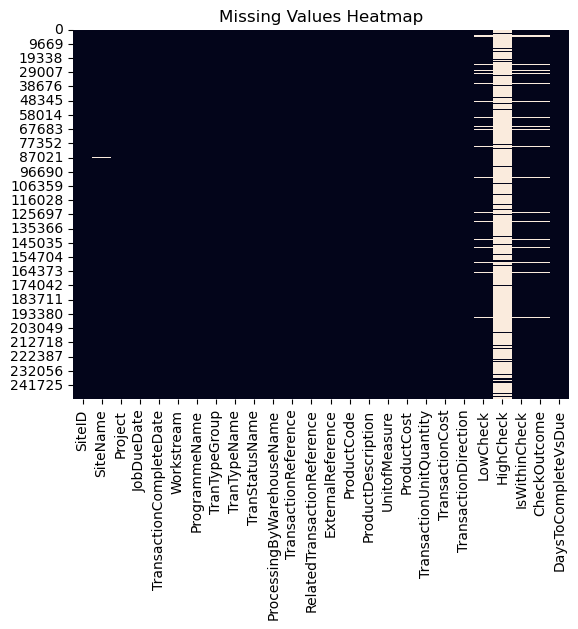

In [8]:
# explore missing values
missing_values_percent = (df_txn.isnull().sum() / len(df_txn)) * 100
missing_values_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_values_percent})
missing_values_df = missing_values_df[missing_values_df['Missing Values'] > 0]
missing_values_df.sort_values(by='Percentage', ascending=False, inplace=True)
display(missing_values_df)

# visualize missing values heatmap
sns.heatmap(df_txn.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

# Treatment of missing values
1. Though, 'HighCheck' column has over 88% missing values, we still keep this column for further analysis as it might contain important information.

2. For 'LowCheck' and 'IsWithinCheck' columns with less than 5% missing values, we will keep them as is for now and consider imputation later if necessary.

In [9]:
df_txn.head()  # display first few rows of the dataframe

,SiteID,SiteName,Project,JobDueDate,TransactionCompleteDate,Workstream,ProgrammeName,TranTypeGroup,TranTypeName,TranStatusName,ProcessingByWarehouseName,TransactionReference,RelatedTransactionReference,ExternalReference,ProductCode,ProductDescription,UnitofMeasure,ProductCost,TransactionUnitQuantity,TransactionCost,TransactionDirection,LowCheck,HighCheck,IsWithinCheck,CheckOutcome,DaysToCompleteVsDue
0,5148230,4 WALMSLEY ROAD MANGERE BRIDGE MANUKAU 2022,Not Project,2025-10-31,2025-11-01,Provisioning,Provisioning,Consume,Sales Order,Completed,AMP COMMUNICATIONS LIMITED_1,SS-00260971,SO-00260971,251029481931,10031013,"XCPSC00527 - MDU Premise Demarcation Point, Mo...",Each,8.81,1.0,8.81,OUT,1.0,NaN,1.0,Within Range,1
1,5148230,4 WALMSLEY ROAD MANGERE BRIDGE MANUKAU 2022,Not Project,2025-10-31,2025-11-01,Provisioning,Provisioning,Consume,Sales Order,Completed,AMP COMMUNICATIONS LIMITED_1,SS-00260971,SO-00260971,251029481931,10031056,760253450 - ITP Gen4 ONT - multiples of 30 (pa...,Each,18.71,1.0,18.71,OUT,1.0,NaN,1.0,Within Range,1
2,5148230,4 WALMSLEY ROAD MANGERE BRIDGE MANUKAU 2022,Not Project,2025-10-31,2025-11-01,Provisioning,Provisioning,Consume,Sales Order,Completed,AMP COMMUNICATIONS LIMITED_1,SS-00260971,SO-00260971,251029481931,10075449,3FE56522AA-ONT Type 200 G-240G-P excl PSU,Each,10.55,1.0,10.55,OUT,1.0,NaN,1.0,Within Range,1
3,5148230,4 WALMSLEY ROAD MANGERE BRIDGE MANUKAU 2022,Not Project,2025-10-31,2025-11-01,Provisioning,Provisioning,Consume,Sales Order,Completed,AMP COMMUNICATIONS LIMITED_1,SS-00260971,SO-00260971,251029481931,10030858,INH8010221 - Fibre Termination Box (ETP). Ver3...,Each,10.55,1.0,10.55,OUT,1.0,NaN,1.0,Within Range,1
4,5148230,4 WALMSLEY ROAD MANGERE BRIDGE MANUKAU 2022,Not Project,2025-10-31,2025-11-01,Provisioning,Provisioning,Consume,Sales Order,Completed,AMP COMMUNICATIONS LIMITED_1,SS-00260971,SO-00260971,251029481931,10190621,3FE49563CA-4TH GEN ONT G-1425G-A incl PSU,Each,72.90,1.0,72.90,OUT,1.0,NaN,1.0,Within Range,1


In [10]:
# Impute missing LowCheck values with median LowCheck per ProductCode
lowcheck_median = (
    df_txn.groupby(["ProductCode"])["LowCheck"]
      .transform("median")
)
df_txn["LowCheck_imputed"] = df_txn["LowCheck"].fillna(lowcheck_median)


In [11]:
df_txn.isnull().sum()  # verify missing values after imputation

SiteID                              0
SiteName                          122
Project                             0
JobDueDate                          0
TransactionCompleteDate             0
Workstream                          0
ProgrammeName                       0
TranTypeGroup                       0
TranTypeName                        0
TranStatusName                      0
ProcessingByWarehouseName           0
TransactionReference                0
RelatedTransactionReference        29
ExternalReference                   0
ProductCode                         0
ProductDescription                  0
UnitofMeasure                       0
ProductCost                         0
TransactionUnitQuantity             0
TransactionCost                     0
TransactionDirection                0
LowCheck                        12332
HighCheck                      221811
IsWithinCheck                   11800
CheckOutcome                    11800
DaysToCompleteVsDue                 0
LowCheck_imp

### There are still some missing values in LowCheck, we can choose to fill them with another method later by using WorkStream.

In [12]:
print(df_txn["LowCheck"].dtype)
print(df_txn["LowCheck"].unique()[:10])


float64
[ 1. nan  3.  5. 10.  2.]


In [13]:
na_groups = df_txn.groupby("ProductCode")["LowCheck"].apply(lambda x: x.isnull().all())
problematic_codes = na_groups[na_groups == True].index.tolist()

print(f"共有 {len(problematic_codes)} 个 ProductCode 组内全是空值，无法通过组内插补。")
print(f"这些组的 ProductCode 示例: {problematic_codes[:5]}")

There are 250 nulls in ProductCode in total，cannot impute within group。
Examples of ProductCode: [6338217, 10030369, 10030390, 10030391, 10030402]


In [14]:
# 1. 计算不同层级的中位数
by_product = df_txn.groupby("ProductCode")["LowCheck"].transform(
    lambda x: x.dropna().median() if len(x.dropna()) > 0 else np.nan
)
by_workstream = df_txn.groupby("Workstream")["LowCheck"].transform(
    lambda x: x.dropna().median() if len(x.dropna()) > 0 else np.nan
)
global_median = df_txn["LowCheck"].median(skipna=True)

# 2. 链式填充：一层套一层
df_txn["LowCheck_imputed"] = (
    df_txn["LowCheck"]
    .fillna(by_product)      # 第一优先级：产品级
    .fillna(by_workstream)   # 第二优先级：业务流级
    .fillna(global_median)   # 第三优先级：全表级（确保 100% 补全）
)

# 3. 验证每一层的效果
print(f"原始空值总数: {df_txn['LowCheck'].isnull().sum()}")
print(f"插补后最终空值数: {df_txn['LowCheck_imputed'].isnull().sum()}")

原始空值总数: 12332
插补后最终空值数: 0


In [15]:
# 2. IsWithinCheck插补（修正版）
df_txn["IsWithinCheck_imputed"] = df_txn["IsWithinCheck"].astype(float)

# 正确逻辑：在范围内=1，超出范围=0
check_logic = df_txn["TransactionUnitQuantity"] >= df_txn["LowCheck_imputed"]
calculated_check = check_logic.map({True: 1.0, False: 0.0})

# 只填充可以计算的部分
can_calculate = df_txn["IsWithinCheck_imputed"].isna() & df_txn["LowCheck_imputed"].notna()
df_txn.loc[can_calculate, "IsWithinCheck_imputed"] = calculated_check[can_calculate]

### Imputation of CheckOutcome completed

In [16]:
# then impute checkoutcome column
conditions = [
    # 1. Below LowCheck (只要比下限小，就判定)
    (df_txn["CheckOutcome"].isna()) & 
    (df_txn["TransactionUnitQuantity"] < df_txn["LowCheck_imputed"]),
    
    # 2. Within Range (必须在两者之间)
    (df_txn["CheckOutcome"].isna()) & 
    (df_txn["TransactionUnitQuantity"] >= df_txn["LowCheck_imputed"]) & 
    (df_txn["HighCheck"].notna()) & 
    (df_txn["TransactionUnitQuantity"] <= df_txn["HighCheck"]),
    
    # 3. Above HighCheck (HighCheck 不为空且超过它)
    (df_txn["CheckOutcome"].isna()) & 
    (df_txn["HighCheck"].notna()) & 
    (df_txn["TransactionUnitQuantity"] > df_txn["HighCheck"])
]

choices = [
    "Below LowCheck",
    "Within Range",
    "Above HighCheck"
]

# 执行填充
# np.select 会按顺序检查条件，如果都不符合，默认保留原值
df_txn["CheckOutcome"] = np.select(conditions, choices, default=df_txn["CheckOutcome"])

# 将剩余的 null 值（即那些既不低于 LowCheck，又因为缺少 HighCheck 无法判定是否超标的行）
# 填充为一个明确的分类标签
df_txn["CheckOutcome"] = df_txn["CheckOutcome"].fillna("unknown")

# 验证结果
print("CheckOutcome 各类别统计：")
print(df_txn["CheckOutcome"].value_counts(dropna=False))


CheckOutcome 各类别统计：
CheckOutcome
Within Range       235354
unknown              9729
Below LowCheck       5778
Above HighCheck       508
Name: count, dtype: int64


### "The CheckOutcome categorical variable was refined by cross-referencing TransactionUnitQuantity with the calibrated LowCheck and HighCheck thresholds. Transactions were categorized as 'Below LowCheck' if they fell short of the minimum requirement. For records where HighCheck was available, values were classified as 'Within Range' or 'Above HighCheck' accordingly. In instances where HighCheck data was absent, the outcome remained undefined to avoid speculative classification, thereby ensuring the stringency of the categorical analysis."

In [17]:
df_txn.isnull().sum()  # verify missing values after imputation
df_txn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251369 entries, 0 to 251368
Data columns (total 28 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   SiteID                       251369 non-null  int64         
 1   SiteName                     251247 non-null  object        
 2   Project                      251369 non-null  object        
 3   JobDueDate                   251369 non-null  datetime64[ns]
 4   TransactionCompleteDate      251369 non-null  datetime64[ns]
 5   Workstream                   251369 non-null  object        
 6   ProgrammeName                251369 non-null  object        
 7   TranTypeGroup                251369 non-null  object        
 8   TranTypeName                 251369 non-null  object        
 9   TranStatusName               251369 non-null  object        
 10  ProcessingByWarehouseName    251369 non-null  object        
 11  TransactionReference      

### Modify data types of certain columns

In [18]:
# change data type of external reference to string
df_txn['SiteID'] = df_txn['SiteID'].astype(str)
df_txn['ExternalReference'] = df_txn['ExternalReference'].astype(str)

###  Delete the duplicate rows

In [19]:
df_txn.head()

,SiteID,SiteName,Project,JobDueDate,TransactionCompleteDate,Workstream,ProgrammeName,TranTypeGroup,TranTypeName,TranStatusName,ProcessingByWarehouseName,TransactionReference,RelatedTransactionReference,ExternalReference,ProductCode,ProductDescription,UnitofMeasure,ProductCost,TransactionUnitQuantity,TransactionCost,TransactionDirection,LowCheck,HighCheck,IsWithinCheck,CheckOutcome,DaysToCompleteVsDue,LowCheck_imputed,IsWithinCheck_imputed
0,5148230,4 WALMSLEY ROAD MANGERE BRIDGE MANUKAU 2022,Not Project,2025-10-31,2025-11-01,Provisioning,Provisioning,Consume,Sales Order,Completed,AMP COMMUNICATIONS LIMITED_1,SS-00260971,SO-00260971,251029481931,10031013,"XCPSC00527 - MDU Premise Demarcation Point, Mo...",Each,8.81,1.0,8.81,OUT,1.0,NaN,1.0,Within Range,1,1.0,1.0
1,5148230,4 WALMSLEY ROAD MANGERE BRIDGE MANUKAU 2022,Not Project,2025-10-31,2025-11-01,Provisioning,Provisioning,Consume,Sales Order,Completed,AMP COMMUNICATIONS LIMITED_1,SS-00260971,SO-00260971,251029481931,10031056,760253450 - ITP Gen4 ONT - multiples of 30 (pa...,Each,18.71,1.0,18.71,OUT,1.0,NaN,1.0,Within Range,1,1.0,1.0
2,5148230,4 WALMSLEY ROAD MANGERE BRIDGE MANUKAU 2022,Not Project,2025-10-31,2025-11-01,Provisioning,Provisioning,Consume,Sales Order,Completed,AMP COMMUNICATIONS LIMITED_1,SS-00260971,SO-00260971,251029481931,10075449,3FE56522AA-ONT Type 200 G-240G-P excl PSU,Each,10.55,1.0,10.55,OUT,1.0,NaN,1.0,Within Range,1,1.0,1.0
3,5148230,4 WALMSLEY ROAD MANGERE BRIDGE MANUKAU 2022,Not Project,2025-10-31,2025-11-01,Provisioning,Provisioning,Consume,Sales Order,Completed,AMP COMMUNICATIONS LIMITED_1,SS-00260971,SO-00260971,251029481931,10030858,INH8010221 - Fibre Termination Box (ETP). Ver3...,Each,10.55,1.0,10.55,OUT,1.0,NaN,1.0,Within Range,1,1.0,1.0
4,5148230,4 WALMSLEY ROAD MANGERE BRIDGE MANUKAU 2022,Not Project,2025-10-31,2025-11-01,Provisioning,Provisioning,Consume,Sales Order,Completed,AMP COMMUNICATIONS LIMITED_1,SS-00260971,SO-00260971,251029481931,10190621,3FE49563CA-4TH GEN ONT G-1425G-A incl PSU,Each,72.90,1.0,72.90,OUT,1.0,NaN,1.0,Within Range,1,1.0,1.0


In [20]:
duplicate_rows = df_txn[df_txn.duplicated(keep=False)]
duplicate_rows.head()

,SiteID,SiteName,Project,JobDueDate,TransactionCompleteDate,Workstream,ProgrammeName,TranTypeGroup,TranTypeName,TranStatusName,ProcessingByWarehouseName,TransactionReference,RelatedTransactionReference,ExternalReference,ProductCode,ProductDescription,UnitofMeasure,ProductCost,TransactionUnitQuantity,TransactionCost,TransactionDirection,LowCheck,HighCheck,IsWithinCheck,CheckOutcome,DaysToCompleteVsDue,LowCheck_imputed,IsWithinCheck_imputed
27597,1811866,38B TE KAUWHATA ROAD TE KAUWHATA TE KAUWHATA 3710,Not Project,2024-04-24,2025-09-08,Provisioning,Provisioning,Consume,Sales Order,Completed,Quarantine Stock,SS-006112,SO-006112,240327947727,10030848,HNZ-RUG01 - Rugged 1-way 500 or 7500m MPB901048/1,Metre,0.7800,13.0,10.1400,OUT,1.0,NaN,1.0,Within Range,502,1.0,1.0
27598,1811866,38B TE KAUWHATA ROAD TE KAUWHATA TE KAUWHATA 3710,Not Project,2024-04-24,2025-09-08,Provisioning,Provisioning,Consume,Sales Order,Completed,Quarantine Stock,SS-006112,SO-006112,240327947727,10030858,INH8010221 - Fibre Termination Box (ETP). Ver3...,Each,10.5500,1.0,10.5500,OUT,1.0,NaN,1.0,Within Range,502,1.0,1.0
27599,1811866,38B TE KAUWHATA ROAD TE KAUWHATA TE KAUWHATA 3710,Not Project,2024-04-24,2025-09-08,Provisioning,Provisioning,Consume,Sales Order,Completed,Quarantine Stock,SS-006112,SO-006112,240327947727,10030860,MPB30608/5C1 - Filoform 5/3.5mm MiniductSeal 2...,Each,2.5095,1.0,2.5095,OUT,1.0,NaN,1.0,Within Range,502,1.0,1.0
27600,1811866,38B TE KAUWHATA ROAD TE KAUWHATA TE KAUWHATA 3710,Not Project,2024-04-24,2025-09-08,Provisioning,Provisioning,Consume,Sales Order,Completed,Quarantine Stock,SS-006112,SO-006112,240327947727,10190621,3FE49563CA-4TH GEN ONT G-1425G-A incl PSU,Each,72.9000,1.0,72.9000,OUT,1.0,NaN,1.0,Within Range,502,1.0,1.0
27601,1811866,38B TE KAUWHATA ROAD TE KAUWHATA TE KAUWHATA 3710,Not Project,2024-04-24,2025-09-08,Provisioning,Provisioning,Consume,Sales Order,Completed,Quarantine Stock,SS-006112,SO-006112,240327947727,10030848,HNZ-RUG01 - Rugged 1-way 500 or 7500m MPB901048/1,Metre,0.7800,13.0,10.1400,OUT,1.0,NaN,1.0,Within Range,502,1.0,1.0


In [21]:
# Deduplicate the dataframe
df_txn_clean = df_txn.drop_duplicates()

# Verify deduplication
print("Original rows:", df_txn.shape[0])
print("After deduplication:", df_txn_clean.shape[0])
print("Removed rows:", df_txn.shape[0] - df_txn_clean.shape[0])

Original rows: 251369
After deduplication: 251276
Removed rows: 93


In [22]:
df_txn_clean.to_csv("/Users/ying/Documents/MasseyUni/MasseyUni_Learning_Business Analytics/capstone project/UCG_transaction_data_cleaned.csv", index=False)

# 2. Data Engineering

第一步：需求数据清洗与全局聚合

目的：确保从 df_txn_clean 中提取出的 8.15M 需求总量被完整保留，并在时间维度上按周对齐。

In [23]:
df_txn_clean.head()

,SiteID,SiteName,Project,JobDueDate,TransactionCompleteDate,Workstream,ProgrammeName,TranTypeGroup,TranTypeName,TranStatusName,ProcessingByWarehouseName,TransactionReference,RelatedTransactionReference,ExternalReference,ProductCode,ProductDescription,UnitofMeasure,ProductCost,TransactionUnitQuantity,TransactionCost,TransactionDirection,LowCheck,HighCheck,IsWithinCheck,CheckOutcome,DaysToCompleteVsDue,LowCheck_imputed,IsWithinCheck_imputed
0,5148230,4 WALMSLEY ROAD MANGERE BRIDGE MANUKAU 2022,Not Project,2025-10-31,2025-11-01,Provisioning,Provisioning,Consume,Sales Order,Completed,AMP COMMUNICATIONS LIMITED_1,SS-00260971,SO-00260971,251029481931,10031013,"XCPSC00527 - MDU Premise Demarcation Point, Mo...",Each,8.81,1.0,8.81,OUT,1.0,NaN,1.0,Within Range,1,1.0,1.0
1,5148230,4 WALMSLEY ROAD MANGERE BRIDGE MANUKAU 2022,Not Project,2025-10-31,2025-11-01,Provisioning,Provisioning,Consume,Sales Order,Completed,AMP COMMUNICATIONS LIMITED_1,SS-00260971,SO-00260971,251029481931,10031056,760253450 - ITP Gen4 ONT - multiples of 30 (pa...,Each,18.71,1.0,18.71,OUT,1.0,NaN,1.0,Within Range,1,1.0,1.0
2,5148230,4 WALMSLEY ROAD MANGERE BRIDGE MANUKAU 2022,Not Project,2025-10-31,2025-11-01,Provisioning,Provisioning,Consume,Sales Order,Completed,AMP COMMUNICATIONS LIMITED_1,SS-00260971,SO-00260971,251029481931,10075449,3FE56522AA-ONT Type 200 G-240G-P excl PSU,Each,10.55,1.0,10.55,OUT,1.0,NaN,1.0,Within Range,1,1.0,1.0
3,5148230,4 WALMSLEY ROAD MANGERE BRIDGE MANUKAU 2022,Not Project,2025-10-31,2025-11-01,Provisioning,Provisioning,Consume,Sales Order,Completed,AMP COMMUNICATIONS LIMITED_1,SS-00260971,SO-00260971,251029481931,10030858,INH8010221 - Fibre Termination Box (ETP). Ver3...,Each,10.55,1.0,10.55,OUT,1.0,NaN,1.0,Within Range,1,1.0,1.0
4,5148230,4 WALMSLEY ROAD MANGERE BRIDGE MANUKAU 2022,Not Project,2025-10-31,2025-11-01,Provisioning,Provisioning,Consume,Sales Order,Completed,AMP COMMUNICATIONS LIMITED_1,SS-00260971,SO-00260971,251029481931,10190621,3FE49563CA-4TH GEN ONT G-1425G-A incl PSU,Each,72.90,1.0,72.90,OUT,1.0,NaN,1.0,Within Range,1,1.0,1.0


In [24]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# 1. 重新检查数据结构
print("=== 数据结构检查 ===")
print(f"df_txn_clean 列: {df_txn_clean.columns.tolist()}")
print(f"df_soh 列: {df_soh.columns.tolist()}")
print(f"df_supplementary 列: {df_supplementary.columns.tolist()}")

print("\n=== TransactionDirection 值分布 ===")
print(df_txn_clean['TransactionDirection'].value_counts())

print("\n=== 唯一ProductCode数量 ===")
print(f"df_txn_clean: {df_txn_clean['ProductCode'].nunique()}")
print(f"df_soh: {df_soh['ProductCode'].nunique()}")
print(f"df_supplementary: {df_supplementary['ProductCode'].nunique()}")

=== 数据结构检查 ===
df_txn_clean 列: ['SiteID', 'SiteName', 'Project', 'JobDueDate', 'TransactionCompleteDate', 'Workstream', 'ProgrammeName', 'TranTypeGroup', 'TranTypeName', 'TranStatusName', 'ProcessingByWarehouseName', 'TransactionReference', 'RelatedTransactionReference', 'ExternalReference', 'ProductCode', 'ProductDescription', 'UnitofMeasure', 'ProductCost', 'TransactionUnitQuantity', 'TransactionCost', 'TransactionDirection', 'LowCheck', 'HighCheck', 'IsWithinCheck', 'CheckOutcome', 'DaysToCompleteVsDue', 'LowCheck_imputed', 'IsWithinCheck_imputed']
df_soh 列: ['SnapshotDateID', 'WarehouseName', 'ProductCode', 'QtyOnHand']
df_supplementary 列: ['WarehouseID', 'ProductCode', 'ProductGroup', 'AvgRequestsPerWeek', 'LeadTime']

=== TransactionDirection 值分布 ===
TransactionDirection
OUT    250777
IN        499
Name: count, dtype: int64

=== 唯一ProductCode数量 ===
df_txn_clean: 609
df_soh: 555
df_supplementary: 479


In [25]:
# ==========================================
# Phase 1: 原始数据清洗与对齐 (Cleaning & Alignment)
# ==========================================
print("Phase 1: Aligning transactions and handling net quantity...")

# 1.1 计算净需求 (Net Quantity)
df_txn_clean['Net_Quantity'] = df_txn_clean.apply(
    lambda x: x['TransactionUnitQuantity'] if x['TransactionDirection'] == 'OUT' 
    else -x['TransactionUnitQuantity'], axis=1
)

# 1.2 时间对齐
df_txn_clean['Week_Start_Date'] = pd.to_datetime(df_txn_clean['TransactionCompleteDate']).dt.to_period('W').dt.to_timestamp()

# ==========================================
# Phase 2: 全局聚合 (Global Aggregation)
# ==========================================
print("Phase 2: Aggregating to Global Weekly Level...")

# 移除了 Max_Weekly_Pressure，回归纯需求聚合
df_weekly_global = df_txn_clean.groupby(['Week_Start_Date', 'ProductCode']).agg({
    'Net_Quantity': 'sum',
    'SiteID': 'nunique'
}).reset_index().rename(columns={
    'Net_Quantity': 'Global_Weekly_Demand'
})

# ==========================================
# Phase 3: 仓库分配与稀疏性处理 (Distribution & Grid)
# ==========================================
print("Phase 3: Handling Warehouse Distribution & Sparsity...")

# 3.1 权重计算
df_supp_calc = df_supplementary.copy()
df_supp_calc['Total_Product_Avg_Req'] = df_supp_calc.groupby('ProductCode')['AvgRequestsPerWeek'].transform('sum')
df_supp_calc['Warehouse_Weight'] = (df_supp_calc['AvgRequestsPerWeek'] / df_supp_calc['Total_Product_Avg_Req']).fillna(0)

# 3.2 需求拆分
df_distributed = pd.merge(df_weekly_global, 
                          df_supp_calc[['ProductCode', 'WarehouseID', 'Warehouse_Weight', 'LeadTime', 'ProductGroup']], 
                          on='ProductCode', how='inner')

df_distributed['Product_Weekly_Demand'] = df_distributed['Global_Weekly_Demand'] * df_distributed['Warehouse_Weight']

# 3.3 构建全时间网格 (解决 0 需求周问题)
all_weeks = pd.date_range(start=df_weekly_global['Week_Start_Date'].min(), 
                          end=df_weekly_global['Week_Start_Date'].max(), freq='W-MON')
grid = pd.MultiIndex.from_product([all_weeks, df_supplementary['ProductCode'].unique(), df_supplementary['WarehouseID'].unique()], 
                                  names=['Week_Start_Date', 'ProductCode', 'WarehouseID'])
df_final = pd.DataFrame(index=grid).reset_index()

# 3.4 合并并填充
df_final = pd.merge(df_final, df_distributed, on=['Week_Start_Date', 'ProductCode', 'WarehouseID'], how='left')
df_final['Product_Weekly_Demand'] = df_final['Product_Weekly_Demand'].fillna(0)

# 填充静态属性
for col in ['LeadTime', 'ProductGroup']:
    df_final[col] = df_final.groupby(['ProductCode', 'WarehouseID'])[col].ffill().bfill()

# ==========================================
# Phase 4: 目标变量构建 (Target Engineering)
# ==========================================
print("Phase 4: Creating Label (Next 6 Weeks Demand)...")

df_final = df_final.sort_values(['WarehouseID', 'ProductCode', 'Week_Start_Date'])
df_final['Target_Next_6Weeks_Demand'] = df_final.groupby(['WarehouseID', 'ProductCode'])['Product_Weekly_Demand'].transform(
    lambda x: x.shift(-1).rolling(window=6, min_periods=1).sum()
).fillna(0)

# 关联当前库存 SOH (用于后期展示，不作为模型预测特征以避免逻辑循环)
latest_soh = df_soh.sort_values('SnapshotDateID').groupby(['ProductCode', 'WarehouseName'])['QtyOnHand'].last().reset_index()
df_final = pd.merge(df_final, latest_soh, 
                    left_on=['ProductCode', 'WarehouseID'], 
                    right_on=['ProductCode', 'WarehouseName'], how='left').fillna({'QtyOnHand': 0})

# ==========================================
# Phase 5: 纯时序特征工程 (Temporal Feature Engineering)
# ==========================================
print("Phase 5: Finalizing Pure Time-Series Features...")

# 5.1 增加深层滞后需求 (Lags)
# 响应教授建议：通过更深的时序结构捕捉脉冲
for i in [1, 2, 3, 4, 6, 8]:
    df_final[f'Lag_{i}W_Demand'] = df_final.groupby(['WarehouseID', 'ProductCode'])['Product_Weekly_Demand'].shift(i)

# 5.2 需求分类 (ADI/CV2) - 教授高度认可的统计分类
def get_pattern(series):
    non_zero = series[series > 0]
    if len(non_zero) <= 1: return 'Lumpy'
    adi = len(series) / len(non_zero)
    cv2 = (non_zero.std() / (non_zero.mean() + 1e-6))**2
    if adi < 1.32 and cv2 < 0.49: return 'Smooth'
    if adi >= 1.32 and cv2 < 0.49: return 'Intermittent'
    if adi < 1.32 and cv2 >= 0.49: return 'Erratic'
    return 'Lumpy'

patterns = df_final.groupby(['ProductCode', 'WarehouseID'])['Product_Weekly_Demand'].apply(get_pattern).reset_index(name='Demand_Pattern')
df_final = pd.merge(df_final, patterns, on=['ProductCode', 'WarehouseID'], how='left')

# ==========================================
# Phase 6: 统计增强与动量分析 (Stats & Momentum)
# ==========================================
print("Phase 6: Generating Rolling Statistics and Momentum...")

# 6.1 & 6.2 滚动统计量 (4周与8周对比)
# 4周捕捉短期波动
df_final['Demand_Mean_4W'] = df_final.groupby(['WarehouseID', 'ProductCode'])['Product_Weekly_Demand'].transform(
    lambda x: x.shift(1).rolling(window=4, min_periods=1).mean()
)
df_final['Demand_Std_4W'] = df_final.groupby(['WarehouseID', 'ProductCode'])['Product_Weekly_Demand'].transform(
    lambda x: x.shift(1).rolling(window=4, min_periods=1).std()
).fillna(0)

# 8周捕捉中长期趋势（响应教授关于巩固统计基础的要求）
df_final['Demand_Mean_8W'] = df_final.groupby(['WarehouseID', 'ProductCode'])['Product_Weekly_Demand'].transform(
    lambda x: x.shift(1).rolling(window=8, min_periods=1).mean()
)
df_final['Demand_Std_8W'] = df_final.groupby(['WarehouseID', 'ProductCode'])['Product_Weekly_Demand'].transform(
    lambda x: x.shift(1).rolling(window=8, min_periods=1).std()
).fillna(0)

# 增加 6周 滚动统计量，直接对应你的 6周 预测目标
df_final['Demand_Mean_6W'] = df_final.groupby(['WarehouseID', 'ProductCode'])['Product_Weekly_Demand'].transform(
    lambda x: x.shift(1).rolling(window=6, min_periods=1).mean()
)
df_final['Demand_Std_6W'] = df_final.groupby(['WarehouseID', 'ProductCode'])['Product_Weekly_Demand'].transform(
    lambda x: x.shift(1).rolling(window=6, min_periods=1).std()
).fillna(0)

# 6.3 需求动量 (Demand Momentum)
# 捕捉需求变化率，纯时序动力学特征
df_final['Demand_Momentum'] = df_final['Lag_1W_Demand'] - df_final['Lag_2W_Demand']

# 6.4 时间周期特征 (Month)
df_final['Month'] = df_final['Week_Start_Date'].dt.month

# 重新清理缺失行 (必须确保在所有 Lag 特征生成后执行)
df_model_ready = df_final.dropna(subset=['Lag_8W_Demand']).copy()

print(f"Phase 6 Complete. Current feature count: {len(df_model_ready.columns)}")
print("All Done! df_model_ready is now purely driven by time-series dynamics.")

Phase 1: Aligning transactions and handling net quantity...
Phase 2: Aggregating to Global Weekly Level...
Phase 3: Handling Warehouse Distribution & Sparsity...
Phase 4: Creating Label (Next 6 Weeks Demand)...
Phase 5: Finalizing Pure Time-Series Features...
Phase 6: Generating Rolling Statistics and Momentum...
Phase 6 Complete. Current feature count: 27
All Done! df_model_ready is now purely driven by time-series dynamics.


# EDA

1. 异构需求分类分析 (Heterogeneous Demand Categorization)

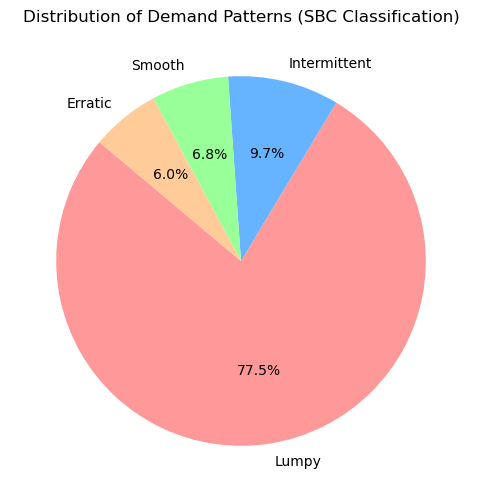

需求模式分布统计：
Demand_Pattern
Lumpy           2227
Intermittent     280
Smooth           194
Erratic          173
Name: count, dtype: int64


In [26]:
# 1.1 统计四种模式的分布
pattern_counts = df_model_ready.groupby(['WarehouseID', 'ProductCode'])['Demand_Pattern'].first().value_counts()

# 1.2 可视化
plt.figure(figsize=(10, 6))
pattern_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('Distribution of Demand Patterns (SBC Classification)')
plt.ylabel('')
plt.show()

print("需求模式分布统计：")
print(pattern_counts)

In [30]:
df_final.head()

,Week_Start_Date,ProductCode,WarehouseID,Global_Weekly_Demand,SiteID,Warehouse_Weight,LeadTime,ProductGroup,Product_Weekly_Demand,Target_Next_6Weeks_Demand,WarehouseName,QtyOnHand,Lag_1W_Demand,Lag_2W_Demand,Lag_3W_Demand,Lag_4W_Demand,Lag_6W_Demand,Lag_8W_Demand,Demand_Pattern,Demand_Mean_4W,Demand_Std_4W,Demand_Mean_8W,Demand_Std_8W,Demand_Mean_6W,Demand_Std_6W,Demand_Momentum,Month
0,2024-09-30,10021188,Hamilton,NaN,NaN,NaN,6.0,Chorus,0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,Lumpy,NaN,0.0,NaN,0.0,NaN,0.0,NaN,9
1,2024-10-07,10021188,Hamilton,NaN,NaN,NaN,8.0,UCG,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,Lumpy,0.0,0.0,0.0,0.0,0.0,0.0,NaN,10
2,2024-10-14,10021188,Hamilton,NaN,NaN,NaN,8.0,UCG,0.0,0.0,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,Lumpy,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
3,2024-10-21,10021188,Hamilton,NaN,NaN,NaN,8.0,UCG,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,Lumpy,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
4,2024-10-28,10021188,Hamilton,NaN,NaN,NaN,8.0,UCG,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,Lumpy,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10


2. 特征重要性分析 (Feature Importance)

In [27]:
# 获取特征重要性
importance = model_rol.get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance (Information Gain)')
plt.show()

print("Top Predictors for Inventory Risk:")
print(importance_df.head(5))

NameError: name 'model_rol' is not defined

2. 需求波动性与稀疏性分析 (Volatility & Sparsity Analysis)

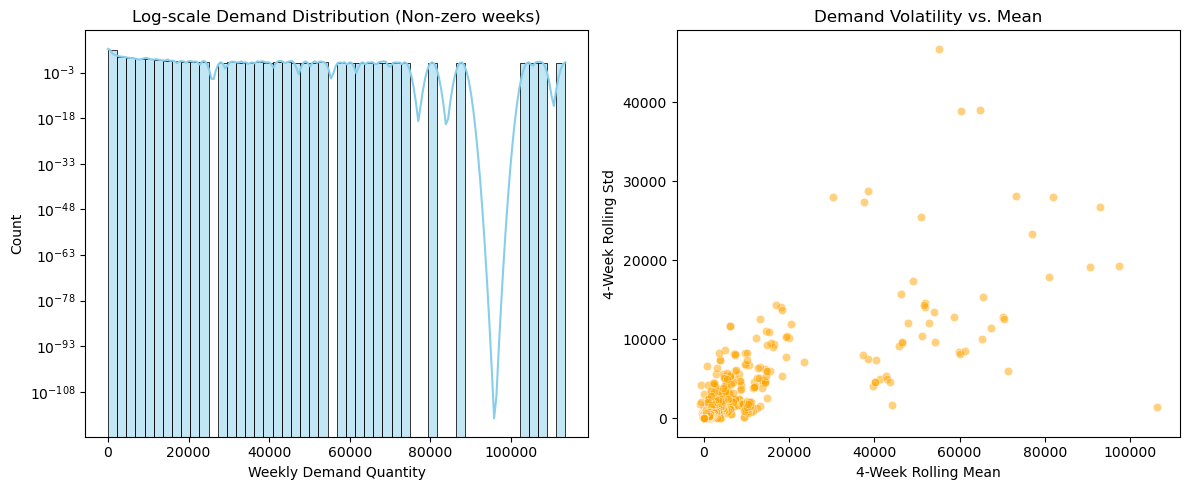

In [41]:
# 建议的替代 EDA：需求波动与统计分布分析
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# 子图1：需求分布的长尾效应（证明 Whale Orders）
plt.subplot(1, 2, 1)
sns.histplot(df_model_ready[df_model_ready['Product_Weekly_Demand'] > 0]['Product_Weekly_Demand'], 
             bins=50, kde=True, color='skyblue')
plt.title('Log-scale Demand Distribution (Non-zero weeks)')
plt.yscale('log') # 使用对数坐标展示长尾
plt.xlabel('Weekly Demand Quantity')

# 子图2：滚动波动率与需求均值的关系（证明 Heterogeneity）
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_model_ready[df_model_ready['Product_Weekly_Demand'] > 0], 
                x='Demand_Mean_4W', y='Demand_Std_4W', alpha=0.5, color='orange')
plt.title('Demand Volatility vs. Mean')
plt.xlabel('4-Week Rolling Mean')
plt.ylabel('4-Week Rolling Std')

plt.tight_layout()
plt.show()

4. 特征相关性热力图 (Feature Correlation)

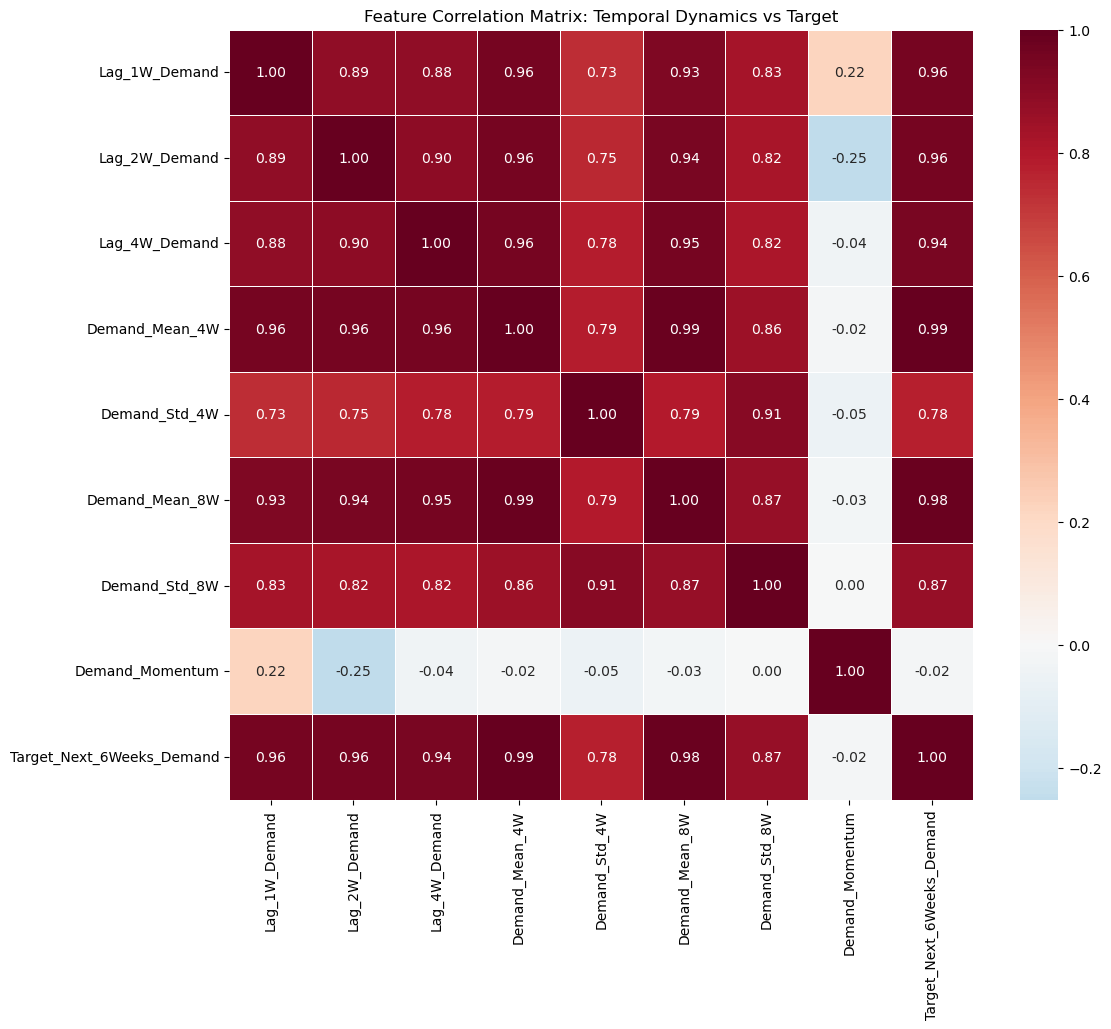

相关性分析完成：请关注 Demand_Std (波动率) 和 Momentum (动量) 与 Target 的关系。


In [42]:

# 1. 选择更新后的纯时序特征列
corr_features = [
    'Lag_1W_Demand', 'Lag_2W_Demand', 'Lag_4W_Demand', 
    'Demand_Mean_4W', 'Demand_Std_4W', 
    'Demand_Mean_8W', 'Demand_Std_8W',
    'Demand_Momentum', 'Target_Next_6Weeks_Demand'
]

# 2. 计算相关系数矩阵
corr_matrix = df_model_ready[corr_features].corr()

# 3. 绘制热力图
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix: Temporal Dynamics vs Target')
plt.show()

print("相关性分析完成：请关注 Demand_Std (波动率) 和 Momentum (动量) 与 Target 的关系。")

5. 典型样本的时间序列可视化 (Time-Series Case Study)

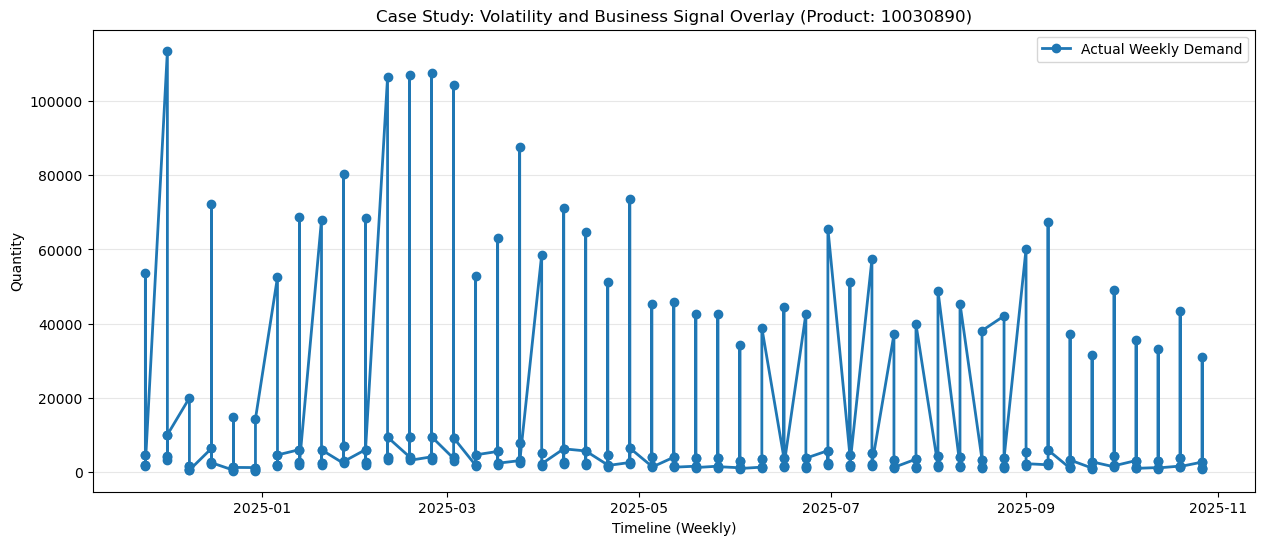

In [43]:
# 1. 选一个需求波动剧烈的产品（通过滚动标准差 Std 寻找，这符合教授对波动率的关注）
# 找到波动率最大的产品之一
sample_prod = df_model_ready.nlargest(10, 'Demand_Std_8W')['ProductCode'].iloc[0]
sample_data = df_model_ready[df_model_ready['ProductCode'] == sample_prod].sort_values('Week_Start_Date')

# 2. 获取原始压力信号（从 df_final 中读取，仅用于业务展示）
# 假设我们要对比的是实际需求和业务系统的 HighCheck 阈值
plt.figure(figsize=(15, 6))

# 绘制实际需求
plt.plot(sample_data['Week_Start_Date'], sample_data['Product_Weekly_Demand'], 
         label='Actual Weekly Demand', marker='o', color='#1f77b4', linewidth=2)

# 绘制 HighCheck 阈值线（如果有）或 压力信号阴影
if 'HighCheck' in sample_data.columns:
    plt.step(sample_data['Week_Start_Date'], sample_data['HighCheck'], 
             where='post', label='HighCheck Threshold (Business Heuristic)', 
             color='red', linestyle='--', alpha=0.6)

plt.title(f'Case Study: Volatility and Business Signal Overlay (Product: {sample_prod})')
plt.xlabel('Timeline (Weekly)')
plt.ylabel('Quantity')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()

6. Lead time敏感度分析

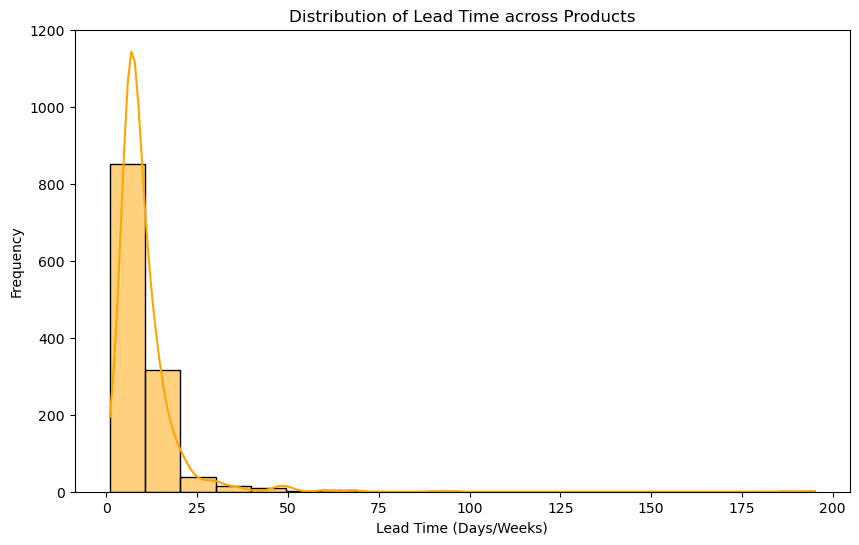

In [ ]:
# EDA 补充：Lead Time 分布可视化
plt.figure(figsize=(10, 6))
sns.histplot(df_supplementary['LeadTime'], bins=20, kde=True, color='orange')
plt.title('Distribution of Lead Time across Products')
plt.xlabel('Lead Time (Days/Weeks)')
plt.ylabel('Frequency')
plt.show()

# Advanced modelling approaches

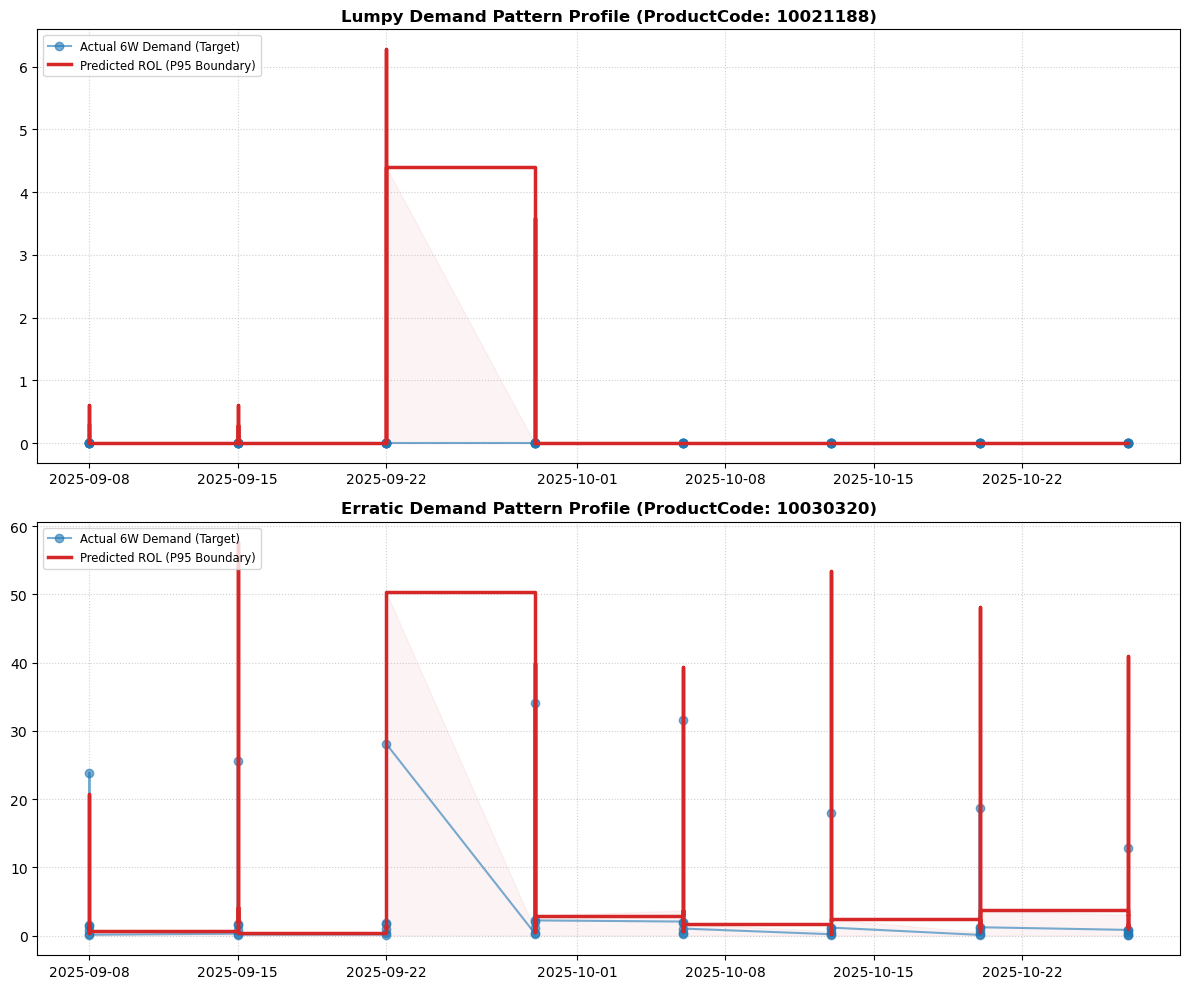

In [45]:
import matplotlib.pyplot as plt
import xgboost as xgb

# ==========================================
# 步骤 1: 模型训练与预测 (基于你的 df_model_ready)
# ==========================================
# 按照你之前的 8 周拆分逻辑
split_date = df_model_ready['Week_Start_Date'].max() - pd.Timedelta(weeks=8)
train_data = df_model_ready[df_model_ready['Week_Start_Date'] <= split_date]
test_data = df_model_ready[df_model_ready['Week_Start_Date'] > split_date]

features = ['Lag_1W_Demand', 'Lag_2W_Demand', 'Lag_4W_Demand', 'Lag_8W_Demand',
            'Demand_Mean_4W', 'Demand_Mean_6W', 'Demand_Mean_8W',
            'Demand_Std_4W', 'Demand_Std_6W', 'Demand_Std_8W',
            'Demand_Momentum', 'Month']
target = 'Target_Next_6Weeks_Demand'

# 训练 P95 分位数模型
model_p95 = xgb.XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.95, n_estimators=100)
model_p95.fit(train_data[features], train_data[target])

# 生成结果数据集 results_df
results_df = test_data.copy()
results_df['Predicted_ROL'] = model_p95.predict(test_data[features])

# ==========================================
# 步骤 2: 自动寻找典型的 Lumpy 和 Erratic ID
# ==========================================
# 找出测试集中最典型的 Lumpy 和 Erratic 产品
example_lumpy = results_df[results_df['Demand_Pattern'] == 'Lumpy']['ProductCode'].iloc[0]
example_erratic = results_df[results_df['Demand_Pattern'] == 'Erratic']['ProductCode'].iloc[0]

# ==========================================
# 步骤 3: 绘制对比图 (用于 Section 4.7)
# ==========================================
def plot_case_study(df, prod_id, pattern_name, ax):
    subset = df[df['ProductCode'] == prod_id].sort_values('Week_Start_Date')
    
    # 实际 6 周需求 (Target)
    ax.plot(subset['Week_Start_Date'], subset['Target_Next_6Weeks_Demand'], 
            label='Actual 6W Demand (Target)', color='#1f77b4', marker='o', alpha=0.6)
    
    # 预测 ROL (P95)
    ax.step(subset['Week_Start_Date'], subset['Predicted_ROL'], 
            label='Predicted ROL (P95 Boundary)', color='#d62728', where='post', linewidth=2.5)
    
    ax.set_title(f"{pattern_name} Profile (ProductCode: {prod_id})", fontsize=12, fontweight='bold')
    ax.fill_between(subset['Week_Start_Date'], 0, subset['Predicted_ROL'], color='#d62728', alpha=0.05)
    ax.legend(loc='upper left', fontsize='small')
    ax.grid(True, linestyle=':', alpha=0.6)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

plot_case_study(results_df, example_lumpy, "Lumpy Demand Pattern", ax1)
plot_case_study(results_df, example_erratic, "Erratic Demand Pattern", ax2)

plt.tight_layout()
plt.show()

第一步：数据准备（时间序列拆分）

In [50]:
# ==========================================
# Phase 7: 数据准备与集拆分 (Data Preparation)
# ==========================================

# 1. 确定拆分点
# 预留最后 8 周作为测试集，这是标准的时序验证方法，教授会认可这种“克制”的处理
max_date = df_model_ready['Week_Start_Date'].max()
split_date = max_date - pd.Timedelta(weeks=8)

# 2. 定义纯时序特征列 (X)
# 这里我们完全移除了业务评分，只保留统计项
features = [
    'Lag_1W_Demand', 'Lag_2W_Demand', 'Lag_4W_Demand', 'Lag_8W_Demand',
    'Demand_Mean_4W', 'Demand_Mean_6W', 'Demand_Mean_8W', # 增加了 6W Mean
    'Demand_Std_4W', 'Demand_Std_6W', 'Demand_Std_8W',   # 增加了 6W Std
    'Demand_Momentum', 'Month'
]

target = 'Target_Next_6Weeks_Demand'

# 3. 拆分数据集
# 确保训练集和测试集在时间上是不重叠的（避免 Data Leakage）
train_data = df_model_ready[df_model_ready['Week_Start_Date'] <= split_date]
test_data = df_model_ready[df_model_ready['Week_Start_Date'] > split_date]

X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]

print(f"Dataset Split Complete:")
print(f"Total Records: {len(df_model_ready)}")
print(f"Training set: {len(X_train)} (Weeks up to {split_date.date()})")
print(f"Test set: {len(X_test)} (Last 8 weeks)")

Dataset Split Complete:
Total Records: 140826
Training set: 117834 (Weeks up to 2025-09-01)
Test set: 22992 (Last 8 weeks)


第二步：模型训练 (XGBoost)

In [51]:
!pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 12.5 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 25.3
    Uninstalling pip-25.3:
      Successfully uninstalled pip-25.3


In [52]:
import xgboost as xgb
from sklearn.metrics import mean_pinball_loss

# 1. 转换为 DMatrix 格式
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# 2. 设置分位数回归参数
# 我们预测 95% 分位数 (P95)，这在物流中代表 95% 的服务水平
# 这种方法输出的预测值直接就是你的 ROL
params = {
    'objective': 'reg:quantileerror',
    'quantile_alpha': 0.95,      # 核心参数：覆盖 95% 的需求风险
    'learning_rate': 0.05,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'tree_method': 'hist'
}

# 3. 训练模型
print("Training Quantile XGBoost Model (P95)...")
model_rol = xgb.train(params, dtrain, num_boost_round=150)

# 4. 在测试集上进行预测
y_pred_rol = model_rol.predict(dtest)

print("Modeling Complete. Predicted ROL values generated for test set.")

Training Quantile XGBoost Model (P95)...
Modeling Complete. Predicted ROL values generated for test set.


3. 模型性能验证代码 (Performance Validation)

覆盖率 (Coverage Rate)：实际需求有多少比例落在你预测的 ROL 之下？（目标是接近 95%）。
平均超量 (Mean Overshoot)：为了安全，我们多备了多少货？（体现资本效率）。

--- Model Reliability Report (P95) ---
Empirical Coverage Rate: 98.13% (Target: 95%)
Average Predicted ROL: 525.40
Model Pinball Loss: 17.0812


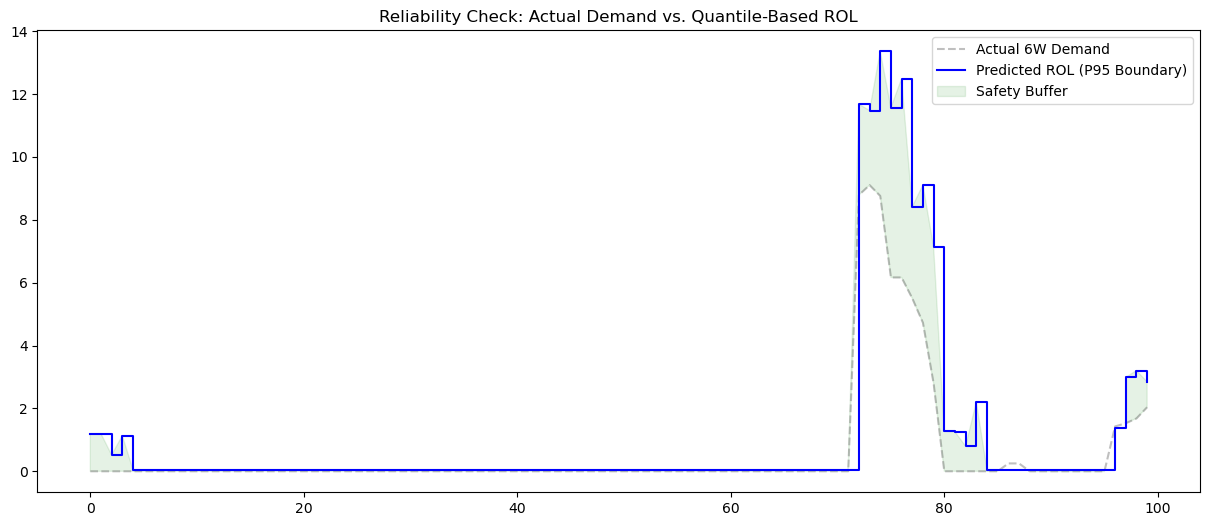

In [53]:
import pandas as pd
import numpy as np

# 1. 整理对比结果
results = pd.DataFrame({
    'Actual_Demand': y_test,
    'Predicted_ROL': y_pred_rol
})

# 2. 计算覆盖率 (The Service Level)
# 如果实际需求 <= 预测出的 ROL，说明没有发生缺货风险
results['In_Stock'] = results['Actual_Demand'] <= results['Predicted_ROL']
coverage_rate = results['In_Stock'].mean()

# 3. 计算 Pinball Loss (分位数回归的标准学术指标)
from sklearn.metrics import mean_pinball_loss
p_loss = mean_pinball_loss(y_test, y_pred_rol, alpha=0.95)

print(f"--- Model Reliability Report (P95) ---")
print(f"Empirical Coverage Rate: {coverage_rate:.2%} (Target: 95%)")
print(f"Average Predicted ROL: {results['Predicted_ROL'].mean():.2f}")
print(f"Model Pinball Loss: {p_loss:.4f}")

# 4. 可视化：实际需求 vs. 预测订货点 (Case Study in Test Set)
# 选取测试集中前 100 个观测点进行对比
plt.figure(figsize=(15, 6))
plt.plot(results['Actual_Demand'].values[:100], label='Actual 6W Demand', color='gray', alpha=0.5, linestyle='--')
plt.step(range(100), results['Predicted_ROL'].values[:100], label='Predicted ROL (P95 Boundary)', color='blue', where='post')
plt.fill_between(range(100), results['Actual_Demand'].values[:100], results['Predicted_ROL'].values[:100], 
                 where=(results['Predicted_ROL'].values[:100] >= results['Actual_Demand'].values[:100]),
                 color='green', alpha=0.1, label='Safety Buffer')
plt.title('Reliability Check: Actual Demand vs. Quantile-Based ROL')
plt.legend()
plt.show()

In [54]:
# 1. 过滤出所有分类为 Erratic 的记录
erratic_skus = df_final[df_final['Demand_Pattern'] == 'Erratic'].copy()

# 2. 计算一个“变异指标”：标准差 / 均值 (使用你已有的特征)
# 这个指标越高，代表这个 Erratic 产品越“名副其实”，波动越剧烈
erratic_skus['Rel_Volatility'] = erratic_skus['Demand_Std_8W'] / (erratic_skus['Demand_Mean_8W'] + 1e-6)

# 3. 找出相对波动最大、且需求量不是特别小的产品 ID
typical_erratic_id = erratic_skus.sort_values(by='Rel_Volatility', ascending=False).iloc[0]['ProductCode']

print(f"建议选取的 Erratic ID 是: {typical_erratic_id}")

建议选取的 Erratic ID 是: 10030838
